# Inverting a Pendulum with Q-Learning

This notebook teaches a pendulum to swing itself upright using tabular
Q-learning, a foundational reinforcement learning (RL) algorithm.

## The problem

Imagine a pendulum hanging straight down. Our goal is to learn a
control policy that applies torque at the pivot so that the pendulum
ends up balanced straight up (the inverted position). The trick: the
torques we can apply are too weak to swing the pendulum up in a single
motion, so the agent has to learn to **pump** energy into the system
(back and forth) before it can get to the top and stabilize.

## State, action, and cost

- **State** `x = (theta, omega)`: angle from the downward vertical and angular velocity.
- **Action** `u`: a torque chosen from a small discrete set, e.g. `{-4, 0, 4}`.
- **Per-step cost**: `g(x, u) = (theta - pi)^2 + 0.01 * omega^2 + 0.0001 * u^2`

The first term punishes being far from the upright position
(`theta = pi`), the second term discourages spinning fast at the top,
and the third term lightly penalizes large control inputs.

## Why Q-learning

Q-learning is **model-free** (the agent does not need to know the
pendulum dynamics ahead of time) and **off-policy** (it can learn the
optimal policy while exploring with a different, more random policy).
We use the **tabular** version: we discretize the continuous state
space into a 50 x 50 grid of (theta, omega) values, and store one
Q-value per (state, action) pair in a lookup table.

> Note: this is a cost-minimization formulation, not a reward-maximization
> one. The math is the same; just flip the sign. Where standard Q-learning
> uses `max` over actions, we will use `min`.


## 1. Setup

Colab has NumPy and Matplotlib pre-installed, so no `pip install` is needed.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import IPython

# Reproducibility: comment out this line if you want fresh randomness each run.
np.random.seed(0)


## 2. The pendulum environment

This cell is the contents of the original repo's `pendulum.py` file,
inlined so the notebook stands alone.

Three things live here:

1. `get_next_state(x, u)` integrates the pendulum's equations of motion
   for one control step (`DELTA_T = 0.1 s`). Internally it uses a smaller
   timestep (`_INTERNAL_DT = 0.01 s`) and integrates 10 sub-steps for
   numerical stability.
2. `simulate(x0, policy, T)` rolls out a trajectory for `T` seconds,
   calling `policy(x)` at every step to get the control.
3. `animate_robot(x)` renders the trajectory as an HTML5 video. Colab
   ships with `ffmpeg`, so this just works.

The physical model is a damped pendulum under gravity:

```
theta_dot  = omega
omega_dot  = u - g * sin(theta) - 0.2 * omega
```

with `omega` clipped to `[-6, 6]` rad/s and `theta` wrapped into `[0, 2*pi)`.


In [2]:
NUMBER_STATES = 2
NUMBER_CONTROLS = 1

MAX_VELOCITY = 6.

DELTA_T = 0.1

# Internal constants for integration. Do not change unless you know why.
_INTERNAL_DT = 0.01
_INTEGRATION_RATIO = 10
_GRAVITY = 9.81


def get_next_state(x, u):
    """
    Integrate the pendulum one control step (DELTA_T seconds).

    Inputs:
        x: state of the pendulum (theta, omega) as a 2D numpy array
        u: control (torque) as a scalar
    Output:
        the state of the pendulum as a 2D numpy array at the end of the step
    """
    x_next = x[0]
    v_next = x[1]
    for i in range(_INTEGRATION_RATIO):
        xx_next = (x_next + _INTERNAL_DT * v_next) % (2 * np.pi)
        v_next = np.clip(
            v_next + _INTERNAL_DT * (u - _GRAVITY * np.sin(x_next) - 0.2 * v_next),
            -MAX_VELOCITY, MAX_VELOCITY
        )
        x_next = xx_next
    return np.array([x_next, v_next])


def simulate(x0, policy, T):
    """
    Simulate the pendulum for T seconds from initial state x0, using a
    policy (a function of x). `policy(x)` must return one scalar control.

    Returns:
        t: time vector (1D)
        x: state trajectory (2 x N+1)
        u: control trajectory (1 x N)
    """
    horizon_length = int(T / DELTA_T)
    x = np.empty([2, horizon_length + 1])
    x[:, 0] = x0
    u = np.empty([horizon_length])
    t = np.zeros([horizon_length + 1])
    for i in range(horizon_length):
        u[i] = policy(x[:, i])
        x[:, i + 1] = get_next_state(x[:, i], u[i])
        t[i + 1] = t[i] + DELTA_T
    return t, x, u


def animate_robot(x):
    """
    Make an HTML5 animation showing the pendulum trajectory `x`.
    `x` should be the 2 x N state array returned by simulate().
    """
    # down-sampling (we want 100 ms DT or higher)
    steps = 1
    use_dt = int(DELTA_T * 1000)
    plotx = x[:, ::steps]

    fig = matplotlib.figure.Figure(figsize=[6, 6])
    matplotlib.backends.backend_agg.FigureCanvasAgg(fig)
    ax = fig.add_subplot(111, autoscale_on=False, xlim=[-1.3, 1.3], ylim=[-1.3, 1.3])
    ax.grid()

    list_of_lines = []

    # the pendulum rod and the bob
    line, = ax.plot([], [], 'k', lw=2)
    list_of_lines.append(line)
    line, = ax.plot([], [], 'o', lw=2)
    list_of_lines.append(line)

    def animate(i):
        for l in list_of_lines:
            l.set_data([], [])

        x_pend = np.sin(plotx[0, i])
        y_pend = -np.cos(plotx[0, i])

        list_of_lines[0].set_data([0., x_pend], [0., y_pend])
        list_of_lines[1].set_data([x_pend, x_pend], [y_pend, y_pend])

        return list_of_lines

    def init():
        return animate(0)

    ani = animation.FuncAnimation(
        fig, animate, np.arange(0, len(plotx[0, :])),
        interval=use_dt, blit=True, init_func=init
    )
    plt.close(fig)
    plt.close(ani._fig)
    IPython.display.display_html(IPython.core.display.HTML(ani.to_html5_video()))


## 3. The cost function

This is the per-step cost `g(x, u)` from the problem statement. The
agent is trying to minimize the (discounted) sum of these over time.


In [3]:
def get_cost(x, u):
    cost = (x[0] - np.pi) ** 2 + 0.01 * (x[1] ** 2) + 0.0001 * (u ** 2)
    return cost


## 4. Discretizing the state space

Q-learning in tabular form needs a finite set of states. We carve the
continuous `(theta, omega)` plane into a 50 x 50 grid:

- `theta` ranges over `[0, 2*pi)` (50 bins, 2*pi is excluded because it is the same angle as 0).
- `omega` ranges over `[-6, 6]` (50 bins).

At every step we will snap the true continuous state to the nearest
grid point for the purpose of Q-table lookup.


In [4]:
# 2pi is excluded because it is the same angle as 0
discretized_theta = np.linspace(0, 2 * np.pi, 50, endpoint=False)

# 50 equally spaced points for omega in [-6, 6]
discretized_omega = np.linspace(-6, 6, 50)


## 5. Helpers used by Q-learning

- `get_policy_and_value_function(q_table)` takes a trained Q-table and
  produces the greedy policy and value function over the grid.
- `find_nearest_value_index(array, value)` snaps a continuous value to
  the closest grid index.

Note on the `argmin` (instead of `argmax`): we are minimizing cost, so
the best action at a state is the one with the **smallest** Q-value.


In [5]:
def get_policy_and_value_function(q_table):
    """Compute the greedy policy and value function from a Q-table."""
    optimal_value_function = np.zeros([50, 50])
    optimal_policy = np.zeros([50, 50])

    for i in range(50):
        for j in range(50):
            opt_index = np.argmin(q_table[i, j, :])  # smallest Q is best (cost)
            optimal_value_function[i, j] = q_table[i, j, opt_index]
            optimal_policy[i, j] = controls[opt_index]

    return optimal_policy, optimal_value_function


def find_nearest_value_index(array, value):
    """Return the index of the element in `array` closest to `value`."""
    index = np.argmin(np.abs(array - value))
    return index


## 6. The Q-learning algorithm

For each episode, the agent starts at the pendulum-down state
`(theta=0, omega=0)` and runs for `N = 100` steps. At each step it:

1. Looks up the greedy action for the current (discretized) state.
2. With probability `epsilon` it ignores that and picks a uniformly
   random action instead (**exploration**).
3. Executes the chosen action, observes the next state, and computes
   the one-step cost.
4. Updates the Q-value using the tabular Q-learning rule (written here
   in cost-minimization form):

   ```
   Q(s, a) <- Q(s, a) + step_size * [cost + alpha * min_a' Q(s', a') - Q(s, a)]
   ```

   where `alpha = 0.99` is the discount factor and `step_size = DELTA_T`
   is the learning rate.

We run 6000 episodes and track the cost of each one in `learning_progress`
(computed using the purely greedy action, so that exploration noise does
not pollute the learning curve).

> Minor modernization note: the original code called
> `np.random.choice(controls, 1)` and then wrapped the result in `int(...)`.
> Newer versions of NumPy (which is what Colab ships with) refuse to convert
> a 1-element array to a Python scalar, so the `, 1` has been dropped in the
> two `np.random.choice` calls below. The algorithm is unchanged.


In [6]:
def q_learning(q_table):
    """Tabular Q-learning over the discretized pendulum state space."""

    # Q-learning parameters
    epsilon = 0.1                 # epsilon-greedy probability (try 0.00001 for less exploration)
    N = 100                       # length of each episode (steps)
    alpha = 0.99                  # discount factor from the cost function
    step_size = DELTA_T           # learning rate

    num_episodes = 0
    learning_progress.clear()

    while num_episodes < 6000:
        x = np.transpose(np.array([0., 0.]))  # always start pointing down, at rest
        num_episodes = num_episodes + 1
        episode_cost = 0

        for i in range(N):
            # Discretize current state
            theta_index = find_nearest_value_index(discretized_theta, x[0])
            omega_index = find_nearest_value_index(discretized_omega, x[1])

            # Epsilon-greedy action selection (we minimize, so argmin)
            index = np.argmin(q_table[theta_index, omega_index, :])
            u_optimal = controls[index]

            u_rand = int(np.random.choice(controls))

            u_chosen = int(np.random.choice([u_optimal, u_rand], p=[1 - epsilon, epsilon]))
            u_chosen_index = np.where(controls == u_chosen)

            # Simulate the environment
            x_next = get_next_state(x, u_chosen)
            theta_index_next = find_nearest_value_index(discretized_theta, x_next[0])
            omega_index_next = find_nearest_value_index(discretized_omega, x_next[1])

            # Costs
            cost = get_cost(x, u_chosen)
            cost_optimal = get_cost(x, u_optimal)

            # Bootstrapped best-next-step Q-value
            Q_next = np.amin(q_table[theta_index_next, omega_index_next, :])

            # Current Q-value estimate
            Q_current = q_table[theta_index, omega_index, u_chosen_index]

            # Temporal-difference error (cost form)
            error = cost + alpha * Q_next - Q_current

            # Track the greedy-action cost for the learning curve
            episode_cost = episode_cost + cost_optimal

            # Q-table update
            q_table[theta_index, omega_index, u_chosen_index] = Q_current + step_size * error

            x = x_next

        learning_progress.append(episode_cost)

    print('Number of Episodes = ', num_episodes)
    return q_table


## 7. The learned controller

Once we have a trained policy table, we wrap it in a function that
`simulate()` can call: given a continuous state, find the nearest grid
point and return the stored action.


In [7]:
def invert_controller(x):
    theta_index = find_nearest_value_index(discretized_theta, x[0])
    omega_index = find_nearest_value_index(discretized_omega, x[1])

    u_optimal = invert_policy[theta_index, omega_index]

    return u_optimal


# Run 1: Controls = [-4, 0, 4]

Train the agent with a maximum torque of 4 N*m in either direction.
This matches the first of the two original notebooks.


In [8]:
# Global parameters for Run 1
controls = np.array([-4, 0, 4])
learning_progress = []


### Train the Q-table

This takes a minute or two on Colab CPU.

In [9]:
Q_Table = np.zeros([50, 50, 3])                     # initialize Q-table
Q_Table_out = q_learning(Q_Table)                   # learn
invert_policy, invert_value_function = get_policy_and_value_function(Q_Table_out)


Number of Episodes =  6000


### Learning progress

Cost per episode (using the greedy action). As training progresses we
expect the curve to drop: the agent is finding increasingly efficient
ways to reach and hold the inverted position.


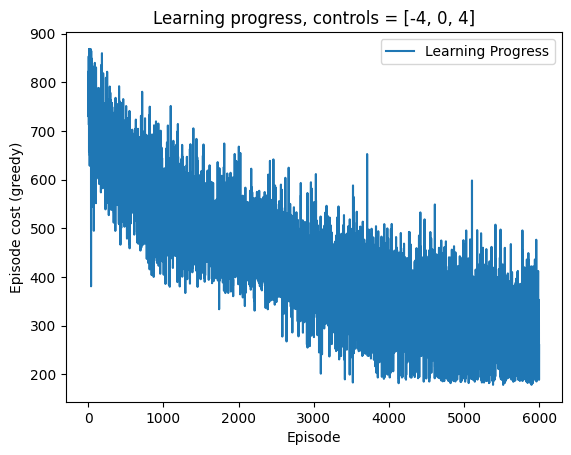

In [10]:
plt.figure()
plt.plot(learning_progress)
plt.legend(['Learning Progress'])
plt.xlabel('Episode')
plt.ylabel('Episode cost (greedy)')
plt.title('Learning progress, controls = [-4, 0, 4]')
plt.show()


### Simulate the learned controller

Run the trained policy for 10 seconds starting from the pendulum-down
state and plot the state and control trajectories.


In [11]:
T = 10.
x0 = np.transpose(np.array([0, 0]))
t, x, u = simulate(x0, invert_controller, T)


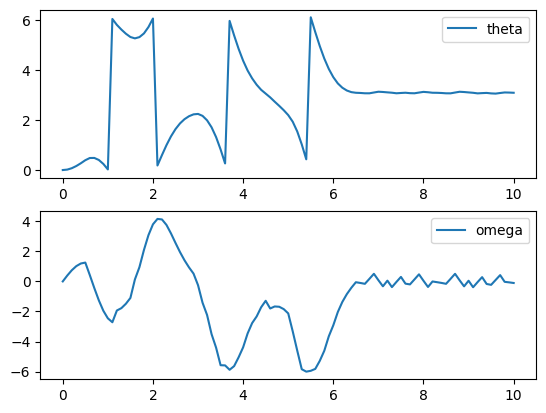

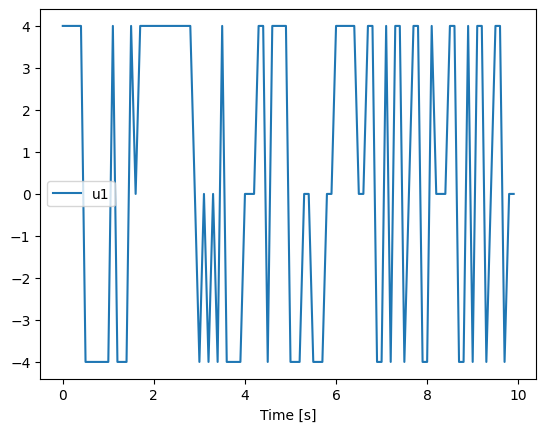

In [12]:
plt.figure()

plt.subplot(2, 1, 1)
plt.plot(t, x[0, :])
plt.legend(['theta'])

plt.subplot(2, 1, 2)
plt.plot(t, x[1, :])
plt.legend(['omega'])

plt.figure()
plt.plot(t[:-1], u.T)
plt.legend(['u1'])
plt.xlabel('Time [s]')
plt.show()


### Animation

An HTML5 video of the pendulum swinging up.

In [13]:
animate_robot(x)


Your browser does not support the video tag.

### Value function and policy

Two heatmaps over the discretized state space:

- **Value function**: the expected discounted cost of starting at each
  `(theta, omega)` and acting greedily from there. Darker means lower
  cost, which in this setup means closer to balanced upright.
- **Policy**: the action the agent takes at each `(theta, omega)`.
  You should see a striped pattern corresponding to the three possible
  torque choices.


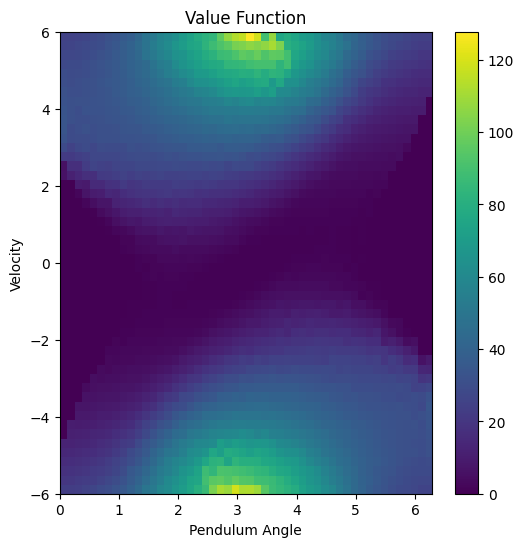

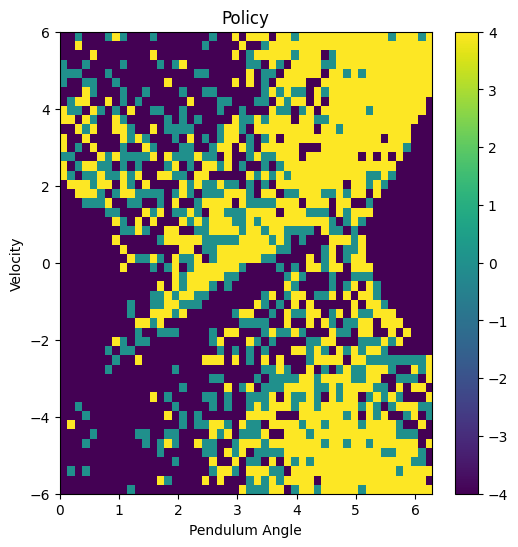

In [14]:
# value function
plt.figure(figsize=[6, 6])
plt.imshow(invert_value_function, extent=[0., 2 * np.pi, -6, 6], aspect='auto')
plt.xlabel('Pendulum Angle')
plt.ylabel('Velocity')
plt.title('Value Function')
plt.colorbar()

# policy
plt.figure(figsize=[6, 6])
plt.imshow(invert_policy, extent=[0., 2 * np.pi, -6, 6], aspect='auto')
plt.xlabel('Pendulum Angle')
plt.ylabel('Velocity')
plt.title('Policy')
plt.colorbar()
plt.show()


# Run 2: Controls = [-5, 0, 5]

Re-train the agent from scratch with a stronger available torque
(5 N*m in either direction). This matches the second of the two
original notebooks. Everything else (algorithm, discretization, cost
function, number of episodes) is identical.

Because the action set is now stronger, we expect the agent to swing
up faster and with a cleaner final trajectory.


In [15]:
# Global parameters for Run 2
controls = np.array([-5, 0, 5])
learning_progress = []


In [16]:
Q_Table = np.zeros([50, 50, 3])
Q_Table_out = q_learning(Q_Table)
invert_policy, invert_value_function = get_policy_and_value_function(Q_Table_out)


Number of Episodes =  6000


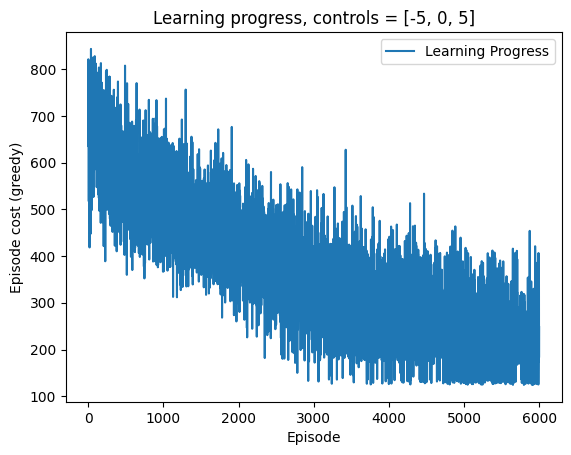

In [17]:
plt.figure()
plt.plot(learning_progress)
plt.legend(['Learning Progress'])
plt.xlabel('Episode')
plt.ylabel('Episode cost (greedy)')
plt.title('Learning progress, controls = [-5, 0, 5]')
plt.show()


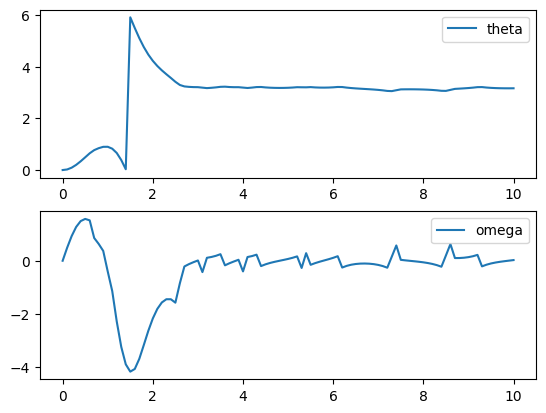

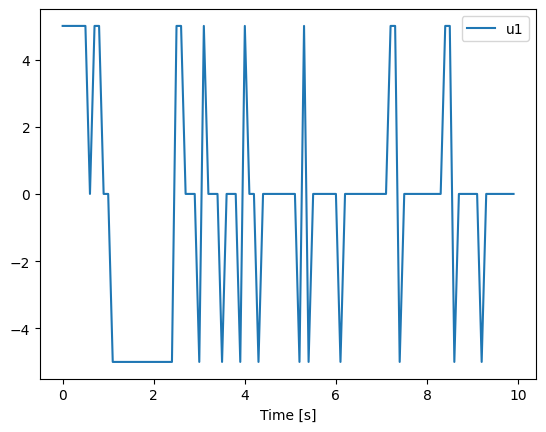

In [18]:
T = 10.
x0 = np.transpose(np.array([0, 0]))
t, x, u = simulate(x0, invert_controller, T)

plt.figure()

plt.subplot(2, 1, 1)
plt.plot(t, x[0, :])
plt.legend(['theta'])

plt.subplot(2, 1, 2)
plt.plot(t, x[1, :])
plt.legend(['omega'])

plt.figure()
plt.plot(t[:-1], u.T)
plt.legend(['u1'])
plt.xlabel('Time [s]')
plt.show()


In [19]:
animate_robot(x)


Your browser does not support the video tag.

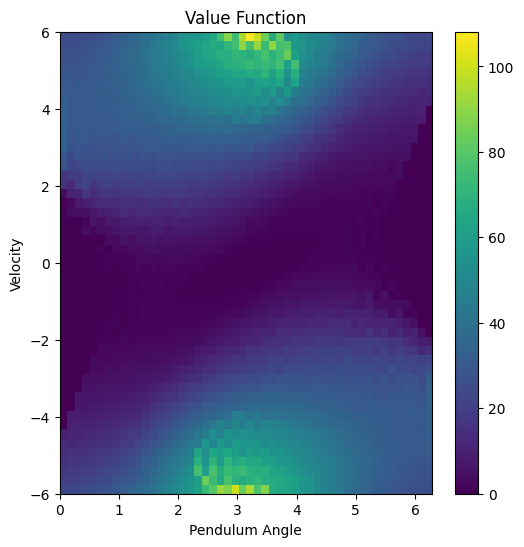

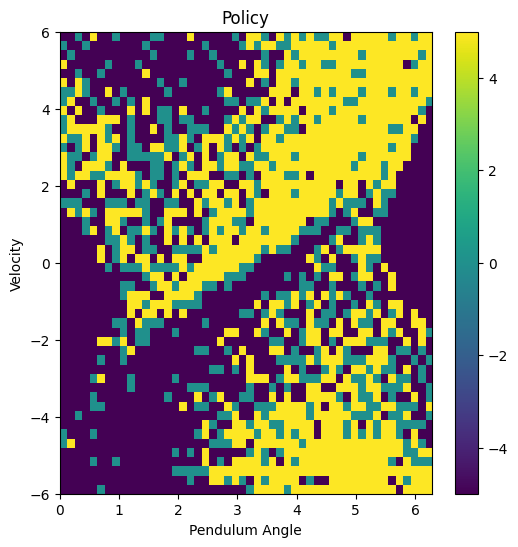

In [20]:
plt.figure(figsize=[6, 6])
plt.imshow(invert_value_function, extent=[0., 2 * np.pi, -6, 6], aspect='auto')
plt.xlabel('Pendulum Angle')
plt.ylabel('Velocity')
plt.title('Value Function')
plt.colorbar()

plt.figure(figsize=[6, 6])
plt.imshow(invert_policy, extent=[0., 2 * np.pi, -6, 6], aspect='auto')
plt.xlabel('Pendulum Angle')
plt.ylabel('Velocity')
plt.title('Policy')
plt.colorbar()
plt.show()


---

# Algorithm Insights: Pseudo-code and Worked Example

---

### (i) Pseudo-code

**Given**

| Parameter | Value |
|:---|:---|
| State | $\mathbf{x} = (\theta, \omega)$, discretized to a $50 \times 50$ grid |
| Actions | $\mathcal{U} = \{-4,\ 0,\ +4\}$ N·m |
| Discount | $\alpha = 0.99$ |
| Learning rate | $\eta = \Delta t = 0.1$ |
| Exploration | $\varepsilon = 0.1$ |
| Training | 6,000 episodes of $N = 100$ steps each |

**Initialise**

$$Q(s, a) \leftarrow 0 \quad \forall\, s, a \qquad\qquad\theta_0 = 0\ \text{rad},\ \omega_0 = 0\ \text{rad/s}$$

**For each episode**, set $\mathbf{x} \leftarrow (\theta_0, \omega_0)$ and repeat for $k = 1 \ldots N$:

**1. Discretise current state**
$$i = \underset{k}{\arg\min}\,|\theta - \theta_k|, \qquad j = \underset{k}{\arg\min}\,|\omega - \omega_k|$$

**2. $\varepsilon$-greedy action selection**
$$u^* = \mathcal{U}\!\left[\underset{a}{\arg\min}\ Q(i,j,a)\right];\quad \text{with prob } \varepsilon \text{ replace with random } u \in \mathcal{U}$$

**3. Simulate one step** ($\Delta t = 0.1$ s via 10 Euler sub-steps of $\delta t = 0.01$ s)
$$\dot\omega = u - g\sin\theta - 0.2\,\omega$$
$$\theta \leftarrow (\theta + \delta t\,\omega) \bmod 2\pi, \qquad \omega \leftarrow \mathrm{clip}(\omega + \delta t\,\dot\omega,\ {-6},\ {+6})$$

**4. Compute step cost**
$$g(\mathbf{x}, u) = (\theta - \pi)^2 + 0.01\,\omega^2 + 0.0001\,u^2$$

**5. Discretise next state:** find $i', j'$ from $\theta', \omega'$

**6. Temporal-difference (TD) error**
$$\delta = g(\mathbf{x}, u) + \alpha \min_{a'} Q(i',j',a') - Q(i,j,u)$$

**7. Q-table update**
$$Q(i,j,u) \leftarrow Q(i,j,u) + \eta\,\delta$$

**8. Advance:** $\mathbf{x} \leftarrow \mathbf{x}'$

**Extract greedy policy after training:**
$$\pi^*(s) = \mathcal{U}\!\left[\underset{a}{\arg\min}\, Q(s, a)\right]$$

---

### (ii) Worked Example - Episode 1, Step 1

**Initial conditions:** $\theta_0 = 0$ rad, $\;\omega_0 = 0$ rad/s (pendulum hanging straight down, at rest)

**Step 1 - Discretise**
$$\theta_0 = 0 \xrightarrow{\text{bin}} i = 0 \qquad (\theta\text{-grid}[0] = 0\ \text{rad})$$
$$\omega_0 = 0 \xrightarrow{\text{bin}} j = 25 \qquad (\omega\text{-grid}[25] = {+0.122}\ \text{rad/s, nearest to } 0)$$

**Step 2 - Action** (Q-table all zeros $\Rightarrow$ ties $\Rightarrow$ first index wins)
$u^* = \mathcal{U}[0] = -4$ N·m
Suppose the $\varepsilon$-check promotes exploration: $u_{\text{chosen}} = +4$ N·m

**Step 3 - Dynamics** ($\sin 0 = 0$, so $\dot\omega \approx u = +4\ \mathrm{rad/s^2}$)

| sub-step $k$ | $\theta$ (rad) | $\omega$ (rad/s) |
|:---:|:---:|:---:|
| 0 | 0.0000 | 0.0000 |
| 1 | 0.0000 | 0.0400 |
| 5 | 0.0040 | 0.1988 |
| 10 | 0.0178 | 0.3918 |

Result: $\theta' \approx 0.018$ rad, $\;\omega' \approx 0.39$ rad/s

**Step 4 - Cost** at $(\theta_0,\, \omega_0,\, u)$
$$g = (0 - \pi)^2 + 0.01(0)^2 + 0.0001(4)^2 = 9.870 + 0 + 0.0016 = \mathbf{9.871}$$

**Step 5 - Discretise next state**
$$\theta' = 0.018\ \text{rad} \;\rightarrow\; i' = 0, \qquad \omega' = 0.39\ \text{rad/s} \;\rightarrow\; j' = 26$$

**Step 6 - TD error**
$$Q_{\text{next}} = \min_{a}\, Q(0,26,a) = 0 \quad \text{(table still all zeros)}$$
$$\delta = 9.871 + 0.99 \times 0 - 0 = \mathbf{9.871}$$

**Step 7 - Update** ($\eta = 0.1$)
$$Q(0,\,25,\,u{=}{+4}) \leftarrow 0 + 0.1 \times 9.871 = \mathbf{0.987}$$

After thousands of episodes, $Q(0,25,{+4})$ converges to the true expected cost of applying $+4$ N·m from rest at the bottom. The agent discovers that alternating $\pm 4$ N·m pumps energy into the pendulum until it can reach and stabilise at $\theta = \pi$.

---

## Credits

Derived from the original repository by **Arjun Raja**:
[github.com/ar6841/Inverting-Pendulum-using-Reinforcement-Learning](https://github.com/ar6841/Inverting-Pendulum-using-Reinforcement-Learning/tree/main).

Colab-compatible fork created by **Benjamin Williams**: [github.com/benwilliams95/Inverting-Pendulum-using-Reinforcement-Learning](https://github.com/benwilliams95/Inverting-Pendulum-using-Reinforcement-Learning).

All algorithm code and physics simulation are the original author's
work; this notebook only consolidates the two Jupyter notebooks and
the `pendulum.py` module into a single file that runs in Google Colab
without modification.
